# **1. DATA LOADING**

# **Importing Librabries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Load dataset
df = pd.read_excel("/content/Flight_dataset[4039].xlsx")

# View data
print(df.head())
print(df.columns)
print(df.info())
print(df.describe())

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left   price  
0          Night           Mumbai  Economy      2.17        1.0  5953.0  
1        Morning           Mumbai  Economy      2.33        1.0  5953.0  
2  Early_Morning           Mumbai  Economy       NaN        1.0  5956.0  
3      Afternoon           Mumbai  Economy      2.25        1.0  5955.0  
4        Morning           Mumbai  Economy      2.33        1.0  5955.0  
Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'dura

# **2. DATA PREPROCESSING**

Data preprocessing was performed to prepare the dataset for machine learning. Missing values in the duration variable were handled using mean imputation. Categorical variables such as the number of stops were converted into numerical format. Unnecessary columns such as “Unnamed” and “flight” were removed as they do not contribute to prediction. Finally, categorical variables were encoded using one-hot encoding to make them suitable for machine learning models.

In [17]:
# Cleaning Inconsistent Data
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df = df.drop(columns=['flight'])

# Handle missing values
df['duration'] = df['duration'].fillna(df['duration'].mean())

# Converting categorical variables
if df['stops'].dtype == 'object':
    df['stops'] = df['stops'].replace({
        'zero': 0,
        'one': 1,
        'two': 2,
        'three': 3
    })

# Feature preparation
df['stops'] = pd.to_numeric(df['stops'], errors='coerce')

# Final check
print(df[['stops', 'duration', 'days_left', 'price']].head())

   stops  duration  days_left   price
0    0.0   2.17000        1.0  5953.0
1    0.0   2.33000        1.0  5953.0
2    0.0  12.22118        1.0  5956.0
3    0.0   2.25000        1.0  5955.0
4    0.0   2.33000        1.0  5955.0


# **3. EDA**

## **Price distribution**

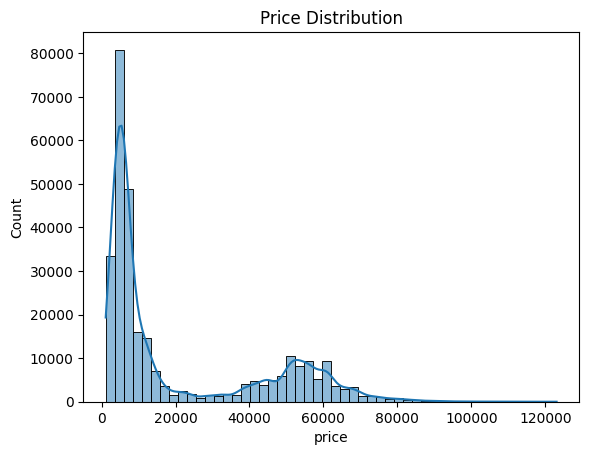

In [6]:
# Price distribution
plt.figure()
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

## **Price vs Duration**

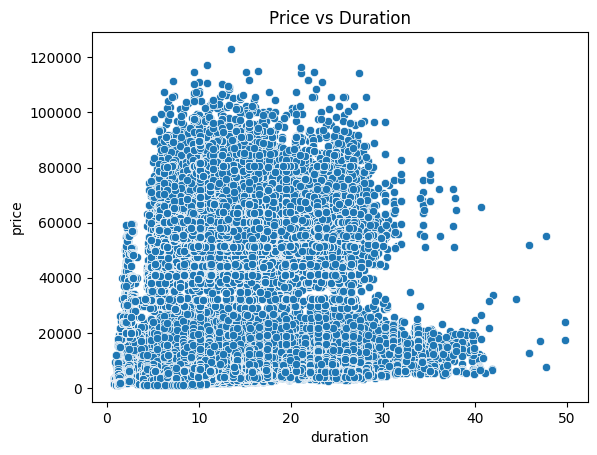

In [7]:
plt.figure()
sns.scatterplot(x=df['duration'], y=df['price'])
plt.title("Price vs Duration")
plt.show()

## **Price vs Days Left**

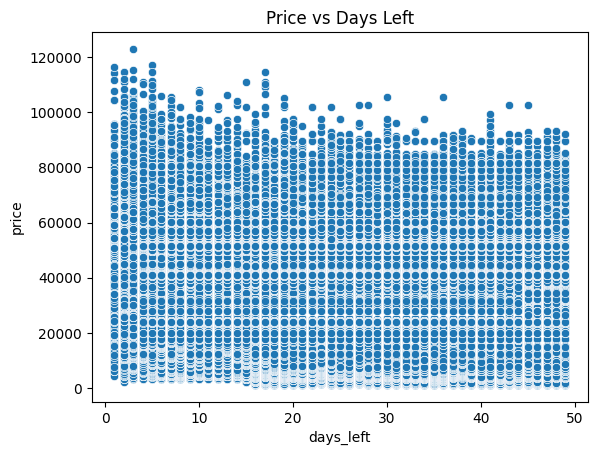

In [8]:
plt.figure()
sns.scatterplot(x=df['days_left'], y=df['price'])
plt.title("Price vs Days Left")
plt.show()

# **Price by Class**

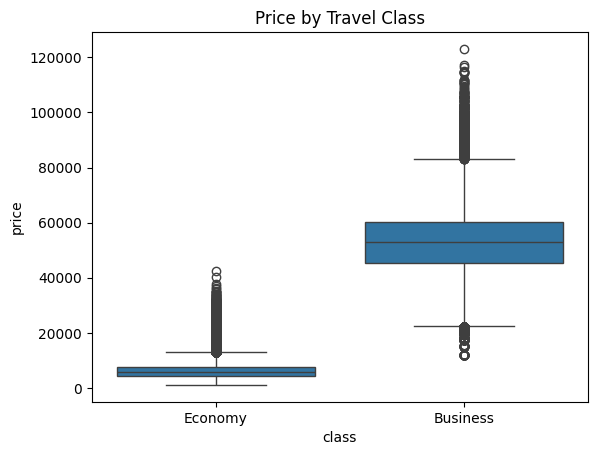

In [23]:
sns.boxplot(x='class', y='price', data=df)
plt.title("Price by Travel Class")
plt.show()
# Figure: Ticket prices are significantly higher for business class compared to economy class.

# **Price by Airline**

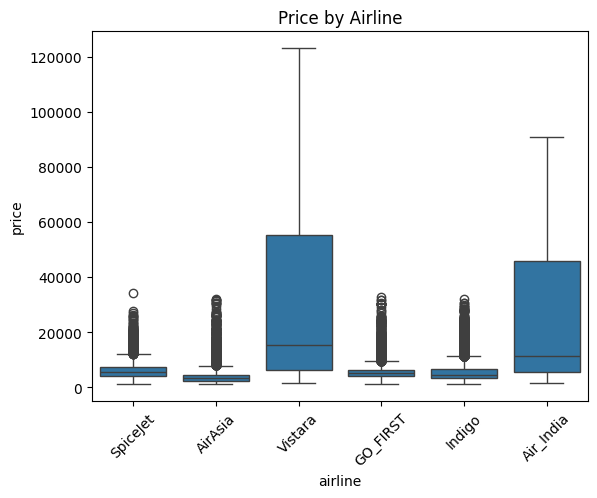

In [24]:
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.title("Price by Airline")
plt.show()
# Figure: Ticket prices vary across airlines, with some airlines charging higher fares than others.

# Price by Stops

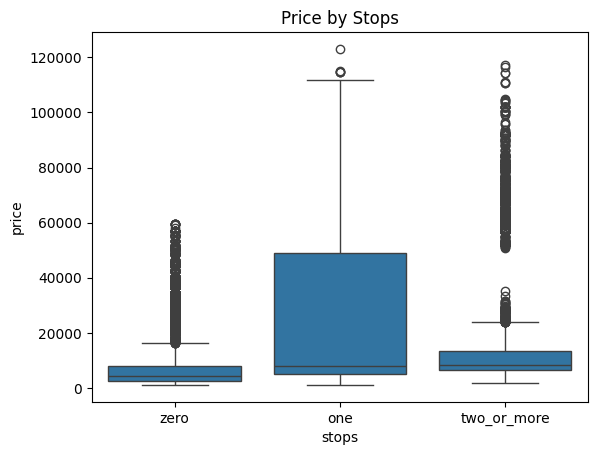

In [25]:
sns.boxplot(x='stops', y='price', data=df)
plt.title("Price by Stops")
plt.show()
# Figure: Flights with more stops tend to have different price distributions compared to direct flights.

# **3.1 Hypothesis Testing**

# ANOVA for categorical vs price

In [36]:
from scipy.stats import f_oneway

def anova_test(feature):
    groups = [group['price'].dropna().values
              for name, group in df.groupby(feature) if len(group) > 1]

    if len(groups) > 1:
        stat, p = f_oneway(*groups)
        print(f"\nFeature: {feature}")
        print("p-value:", p)

        if p < 0.05:
            print("Reject Null Hypothesis")
        else:
            print("Fail to Reject Null")
    else:
        print(f"{feature}: Not enough data for ANOVA")

# Run tests
for col in ['airline', 'class', 'source_city', 'destination_city', 'stops']:
    anova_test(col)


Feature: airline
p-value: 0.0
Reject Null Hypothesis

Feature: class
p-value: 0.0
Reject Null Hypothesis

Feature: source_city
p-value: 2.8084943634915423e-154
Reject Null Hypothesis

Feature: destination_city
p-value: 4.1554087208383966e-206
Reject Null Hypothesis

Feature: stops
p-value: 0.0
Reject Null Hypothesis


H0: Ticket price does not vary across airlines  
H1: Ticket price varies across airlines  
Test: One-way ANOVA  
Decision: Reject H0  
Interpretation: Airline significantly influences ticket price.

# **4. CORRELATION ANALYSIS**

              stops  duration  days_left     price
stops      1.000000  0.523786   0.002855  0.196050
duration   0.523786  1.000000  -0.039210  0.204219
days_left  0.002855 -0.039210   1.000000 -0.091970
price      0.196050  0.204219  -0.091970  1.000000


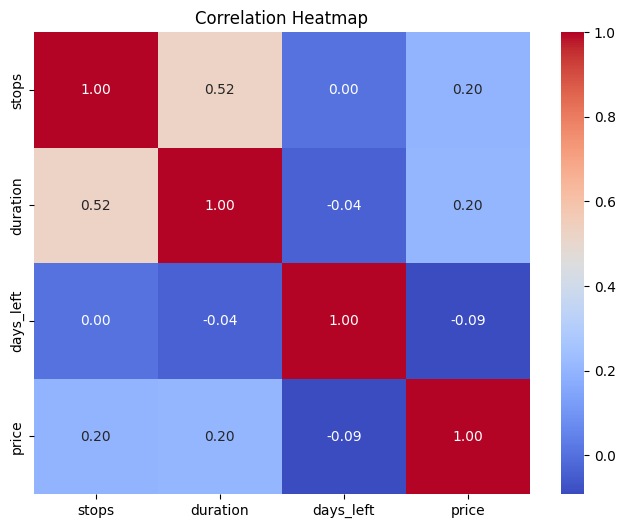

In [9]:
# Select required numeric features ONLY
numeric_df = df[['stops', 'duration', 'days_left', 'price']]

# Correlation matrix
corr_matrix = numeric_df.corr()

print(corr_matrix)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## **5. Data Cleaning**

In [10]:
# Remove unwanted columns safely
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Fix duration (continuous)
df['duration'] = df['duration'].fillna(df['duration'].mean())

# Fix stops (categorical → numeric)
df['stops'] = df['stops'].replace({
    'zero': 0,
    'one': 1,
    'two': 2,
    'three': 3
})

df['stops'] = pd.to_numeric(df['stops'], errors='coerce')

# Fill stops with median (better than 0)
df['stops'] = df['stops'].fillna(df['stops'].median())

# Drop rows where price is missing (important)
df = df.dropna(subset=['price'])

# OPTIONAL: if still any numeric missing values
df = df.fillna(df.mean(numeric_only=True))

# Final check
print(df.isnull().sum())

# ENCODING

df_encoded = pd.get_dummies(df, drop_first=True)

# Features
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


## **6. FEATURE SELECTION**

Features such as airline, class, duration, days_left, stops, source city, and destination city were selected as they are expected to influence ticket pricing based on travel demand, operational cost, and booking behavior.

In [20]:
# Convert categorical variables to numeric
df_encoded = pd.get_dummies(df, drop_first=True)

# Features and target
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

print("Missing values in X:", X.isnull().sum().sum())

print(X.shape)

Missing values in X: 0
(300148, 29)


# **7. MACHINE LEARNING MODELS**

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=8,
    n_jobs=-1,
    random_state=42
)
# Train Random Forest model
rf.fit(X_train, y_train)

print("Train R2:", rf.score(X_train, y_train))
print("Test R2:", rf.score(X_test, y_test))

# Cross Validation

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

print("CV Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

# Ridge REgression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge.coef_
})


coef_df['abs_coef'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

print(coef_df[['Feature', 'Coefficient']].head(10))

Train R2: 0.956444076139421
Test R2: 0.9551612007158732
CV Scores: [0.61102334 0.61701858 0.60215782 0.88669225 0.28877112]
Average CV Score: 0.6011326223494515
                       Feature   Coefficient
28               class_Economy -44805.164611
0                        stops   7586.704048
7              airline_Vistara   3891.857044
6             airline_SpiceJet   1964.366885
5               airline_Indigo   1859.326172
10       source_city_Hyderabad  -1738.149184
25  destination_city_Hyderabad  -1733.511701
24      destination_city_Delhi  -1658.675203
11         source_city_Kolkata   1619.541278
15   departure_time_Late_Night   1576.304581


# **8. MODEL EVALUATION**


Linear Regression
R2: 0.9109103412514998
RMSE: 6775.315775170484
MAPE: 0.46447781743535205
RMSLE: 1.8460921649857744

Random Forest
R2: 0.9551612007158732
RMSE: 4806.654213793684
MAPE: 0.1906677569424464
RMSLE: 0.25037081489613533

Ridge Regression
R2: 0.910910379323596
RMSE: 6775.314327468783
MAPE: 0.46447138473413235
RMSLE: 1.846000748881653

Model Comparison Table:
               Model        R2         RMSE      MAPE     RMSLE
0  Linear Regression  0.910910  6775.315775  0.464478  1.846092
1   Ridge Regression  0.910910  6775.314327  0.464471  1.846001
2      Random Forest  0.955161  4806.654214  0.190668  0.250371


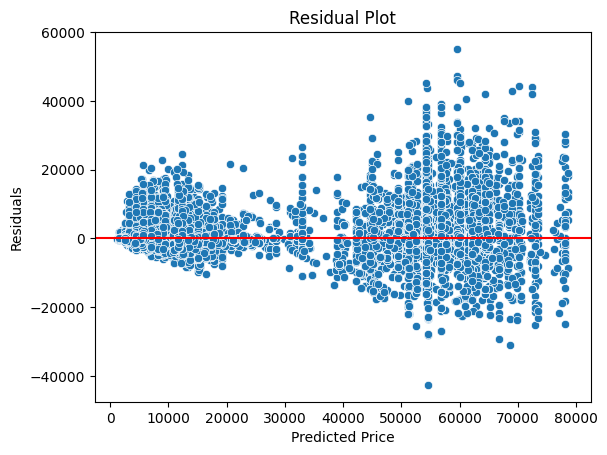

In [35]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_squared_log_error
import numpy as np
import pandas as pd

# Predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
ridge_pred = ridge.predict(X_test)

# Evaluation function
def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    #  RMSLE
    y_true_safe = np.maximum(y_true, 1)
    y_pred_safe = np.maximum(y_pred, 1)
    rmsle = np.sqrt(mean_squared_log_error(y_true_safe, y_pred_safe))

    print(f"\n{name}")
    print("R2:", r2)
    print("RMSE:", rmse)
    print("MAPE:", mape)
    print("RMSLE:", rmsle)

    return r2, rmse, mape, rmsle

# Store results
r2_lr, rmse_lr, mape_lr, rmsle_lr = evaluate(y_test, lr_pred, "Linear Regression")
r2_rf, rmse_rf, mape_rf, rmsle_rf = evaluate(y_test, rf_pred, "Random Forest")
r2_ridge, rmse_ridge, mape_ridge, rmsle_ridge = evaluate(y_test, ridge_pred, "Ridge Regression")



# MODEL COMPARISON TABLE

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest'],
    'R2': [r2_lr, r2_ridge, r2_rf],
    'RMSE': [rmse_lr, rmse_ridge, rmse_rf],
    'MAPE': [mape_lr, mape_ridge, mape_rf],
    'RMSLE': [rmsle_lr, rmsle_ridge, rmsle_rf]
})

print("\nModel Comparison Table:")
print(results)

# Residual Plot

import seaborn as sns
import matplotlib.pyplot as plt

residuals = y_test - rf_pred

plt.figure()
sns.scatterplot(x=rf_pred, y=residuals)
plt.axhline(0, color='red')

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.show()

# **9. INTERPRETATION**

The model does not include external factors such as seasonal demand, fuel prices, or holidays. Additionally, Random Forest models are less interpretable compared to linear models, and predictions may not generalise to future market conditions.

                       Feature  Importance
1588             class_Economy    0.920854
1                     duration    0.042838
2                    days_left    0.011268
7              airline_Vistara    0.006267
3            airline_Air_India    0.004525
1569         source_city_Delhi    0.002669
1587   destination_city_Mumbai    0.001725
1586  destination_city_Kolkata    0.001545
1584    destination_city_Delhi    0.001372
1571       source_city_Kolkata    0.001232


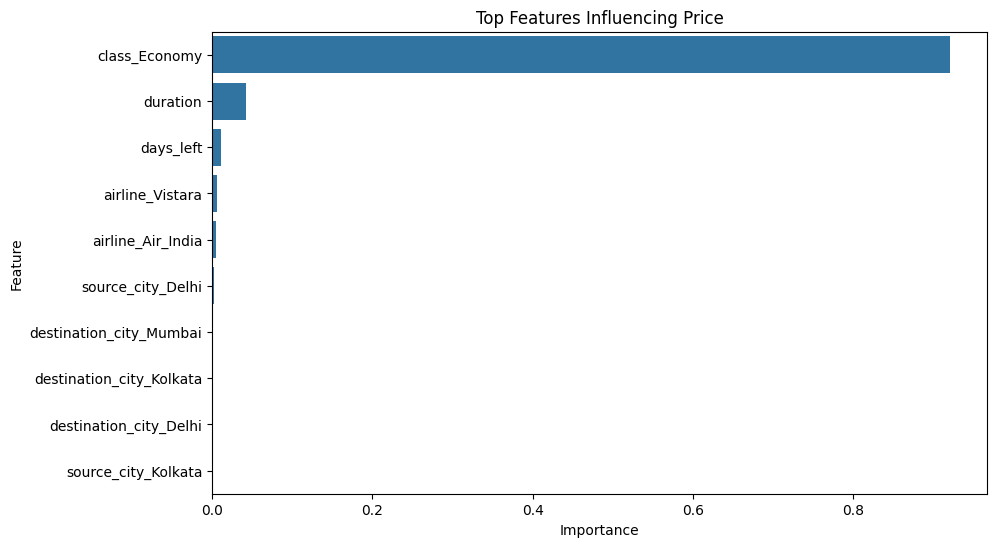

In [16]:
# Feature importance (Random Forest)
importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top Features Influencing Price")
plt.show()

# **10. BUSINESS RECOMMENDATIONS**

Passengers should book tickets earlier, as prices tend to increase when the number of days left decreases. Airlines can use dynamic pricing strategies based on demand patterns, travel class, and duration to maximise revenue. Travel platforms can improve user experience by providing price prediction tools and personalised recommendations based on historical trends.